# Microsoft/PyWhy EconML on the Hillstrom randomized email experiment

## tl;dr

The package is **EconML** (not “EcoML”). On the same untouched holdout, all
five EconML average-effect estimates fall within the experimental 95% CI.
The **T-Learner** has the highest normalized Qini (**0.0183**), while
**CausalForestDML** has the lowest decile calibration RMSE (**0.0257**).

DML reduces nuisance-model bias through orthogonalization and cross-fitting;
it is not guaranteed to win every finite-sample uplift ranking.

## Context & Methods

This notebook compares EconML S-, T-, X-, and DR-Learners with
`CausalForestDML`, a nonlinear double/debiased machine-learning estimator.
The data design, feature allowlist, split, base-forest capacity, primary
outcome, and RCT validation functions are shared with notebook 01.

Random assignment is represented by a constant-prior propensity model for
orthogonal estimators. No propensity model is allowed to invent treatment
selection that the experiment did not have.

## Data

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.exceptions import DataConversionWarning

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

RAW_PATH = ROOT / "data" / "raw" / "hillstrom_email_rct.csv"
PROCESSED_PATH = ROOT / "data" / "processed" / "hillstrom_mens_email_vs_control.csv"
ARTIFACT_DIR = ROOT / "artifacts"
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")

In [2]:
from causal_benchmark.hillstrom import (
    load_or_create_hillstrom_contrast,
    split_hillstrom_arrays,
    standardized_mean_differences,
)
from causal_benchmark.plotting import set_plot_style
from causal_benchmark.rct_evaluation import randomized_difference

set_plot_style()
data = load_or_create_hillstrom_contrast(RAW_PATH, PROCESSED_PATH)
arrays = split_hillstrom_arrays(data)
holdout = randomized_difference(arrays["y_test"], arrays["t_test"])
summary = pd.Series({
    "binary_contrast_customers": len(data),
    "training_customers": int((data["split"] == "train").sum()),
    "holdout_customers": int((data["split"] == "test").sum()),
    "treated_holdout_customers": holdout["treated_n"],
    "control_holdout_customers": holdout["control_n"],
    "rct_visit_uplift": holdout["estimate"],
    "rct_ci_lower": holdout["ci_lower"],
    "rct_ci_upper": holdout["ci_upper"],
    "maximum_absolute_SMD": standardized_mean_differences(data)["abs_smd"].max(),
}, name="value")
display(summary.to_frame().style.format(precision=4))
print("Encoded features:", ", ".join(arrays["feature_names"]))

,value
binary_contrast_customers,42613.0000
training_customers,29829.0000
holdout_customers,12784.0000
treated_holdout_customers,6392.0000
control_holdout_customers,6392.0000
rct_visit_uplift,0.0735
rct_ci_lower,0.0613
rct_ci_upper,0.0857
maximum_absolute_SMD,0.0137


Encoded features: recency, history, mens, womens, newbie, zip_code_Rural, zip_code_Surburban, zip_code_Urban, channel_Multichannel, channel_Phone, channel_Web


The primary binary contrast has 42,613 customers. A seeded, treatment-stratified
70/30 split creates the same 29,829 training rows and 12,784 holdout rows for
every implementation. The holdout contains exactly 6,392 customers per arm.

## Results

### 1. Fit meta-learners, DR-Learner, and CausalForestDML

In [3]:
from causal_benchmark.econml_runner import run_econml_rct_benchmark

result = run_econml_rct_benchmark(data, artifact_dir=ARTIFACT_DIR)
metric_columns = [
    "model", "predicted_ate", "ate_abs_error", "ate_within_rct_95ci",
    "qini_score", "auuc_score", "calibration_rmse", "calibration_rank",
    "fit_seconds",
]
display(result.metrics[metric_columns].style.format(precision=4))

,model,predicted_ate,ate_abs_error,ate_within_rct_95ci,qini_score,auuc_score,calibration_rmse,calibration_rank,fit_seconds
0,T-Learner,0.0764,0.0029,True,0.0183,0.5168,0.0451,0.2848,2.0768
1,CausalForestDML,0.0780,0.0045,True,0.0177,0.5143,0.0257,0.1879,10.6024
2,S-Learner,0.0773,0.0037,True,0.0167,0.5148,0.0408,0.1515,2.2764
3,X-Learner,0.0771,0.0036,True,0.0122,0.5073,0.0304,0.1152,4.3116
4,DR-Learner,0.0769,0.0033,True,-0.0073,0.4909,0.0333,-0.1515,7.7090


### 2. Compare uplift ranking on the randomized holdout

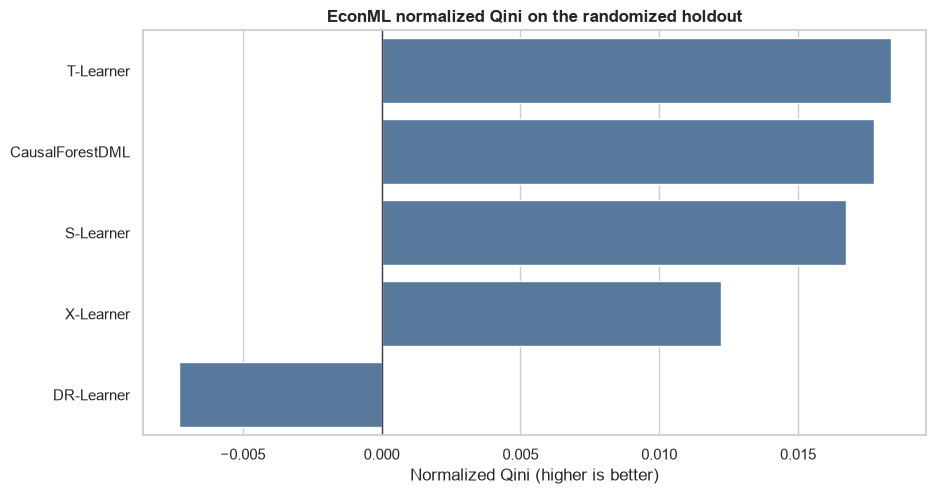

In [4]:
from causal_benchmark.plotting import plot_rct_metric

plot_rct_metric(
    result.metrics,
    "qini_score",
    title="EconML normalized Qini on the randomized holdout",
    x_label="Normalized Qini (higher is better)",
)
plt.show()

### 3. Compare model-implied ATEs with the experimental interval

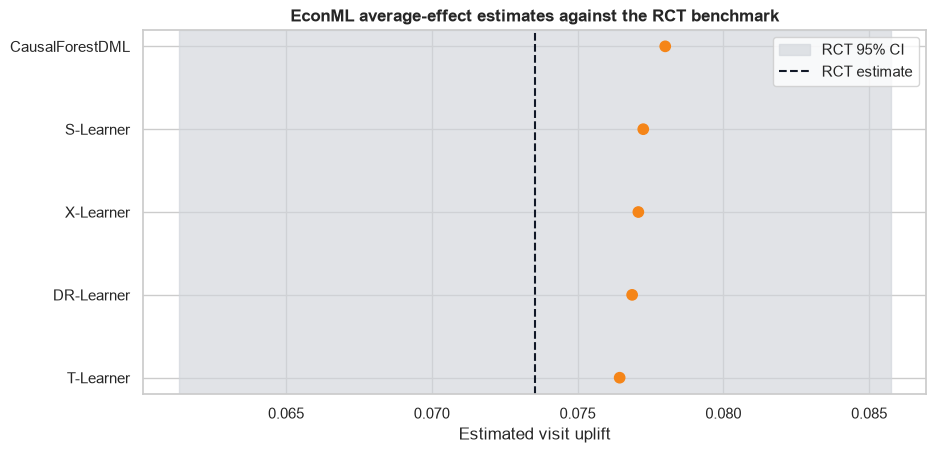

In [5]:
from causal_benchmark.plotting import plot_ate_against_rct

plot_ate_against_rct(
    result.metrics,
    title="EconML average-effect estimates against the RCT benchmark",
)
plt.show()

### 4. Inspect CausalForestDML calibration

,uplift_decile,customers,treated_n,control_n,mean_predicted_cate,observed_rct_uplift,uplift_ci_lower,uplift_ci_upper
0,1,1279,620,659,0.0369,0.0631,0.0286,0.0977
1,2,1278,625,653,0.0540,0.0632,0.0274,0.0991
2,3,1278,623,655,0.0618,0.0606,0.0255,0.0956
3,4,1279,666,613,0.0687,0.0937,0.0547,0.1326
4,5,1278,639,639,0.0747,0.0782,0.0398,0.1167
5,6,1278,651,627,0.0806,0.0631,0.0236,0.1025
6,7,1279,629,650,0.0869,0.0672,0.0290,0.1055
7,8,1278,637,641,0.0938,0.0636,0.0238,0.1033
8,9,1278,657,621,0.1029,0.1140,0.0732,0.1547
9,10,1279,645,634,0.1197,0.0608,0.0175,0.1040


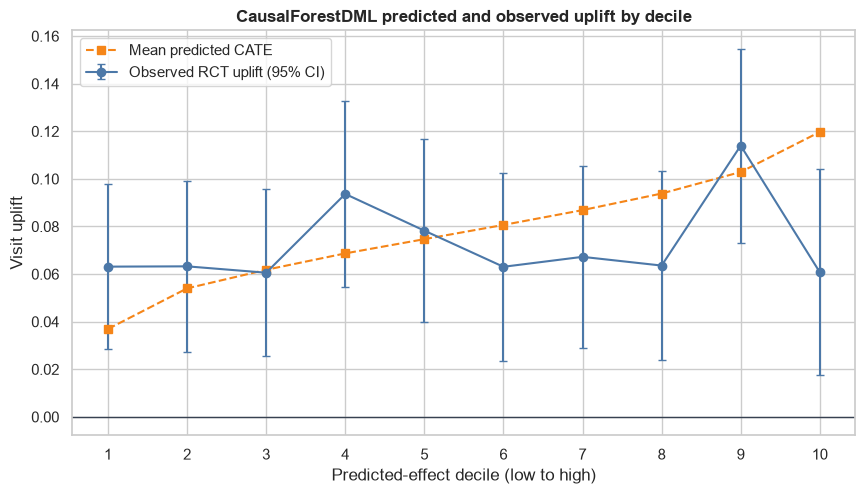

In [6]:
from causal_benchmark.plotting import plot_uplift_calibration
from causal_benchmark.rct_evaluation import uplift_calibration_table

calibration = uplift_calibration_table(
    result.predictions["outcome"],
    result.predictions["treatment"],
    result.predictions["CausalForestDML"],
)
display(calibration.style.format(precision=4))
plot_uplift_calibration(
    calibration,
    title="CausalForestDML predicted and observed uplift by decile",
)
plt.show()

### 5. Separate three different definitions of ‘best’

In [7]:
leaders = pd.DataFrame([
    result.metrics.sort_values("qini_score", ascending=False).iloc[0],
    result.metrics.sort_values("calibration_rmse").iloc[0],
    result.metrics.sort_values("ate_abs_error").iloc[0],
], index=["Qini ranking", "Calibration RMSE", "ATE absolute error"])
display(leaders[["model", "qini_score", "calibration_rmse", "ate_abs_error"]]
        .style.format(precision=4))

,model,qini_score,calibration_rmse,ate_abs_error
Qini ranking,T-Learner,0.0183,0.0451,0.0029
Calibration RMSE,CausalForestDML,0.0177,0.0257,0.0045
ATE absolute error,T-Learner,0.0183,0.0451,0.0029


## Takeaways

In [8]:
qini_winner = result.metrics.sort_values("qini_score", ascending=False).iloc[0]
calibrated = result.metrics.sort_values("calibration_rmse").iloc[0]
inside = int(result.metrics["ate_within_rct_95ci"].sum())
print(
    f"Best EconML ranking: {qini_winner['model']} "
    f"(Qini={qini_winner['qini_score']:.4f})."
)
print(
    f"Lowest calibration RMSE: {calibrated['model']} "
    f"({calibrated['calibration_rmse']:.4f})."
)
print(f"ATE estimates inside the RCT 95% CI: {inside}/{len(result.metrics)}.")

Best EconML ranking: T-Learner (Qini=0.0183).
Lowest calibration RMSE: CausalForestDML (0.0257).
ATE estimates inside the RCT 95% CI: 5/5.


CausalForestDML calibrates the ten uplift groups best on this holdout, but
the T-Learner ranks customers somewhat better by Qini. The distinction is
useful in interviews: DML is an estimation framework, whereas the winning
metric depends on the actual marketing decision.